# Exploratory Data Analysis on TIPS DATASET


This project explores patterns in tipping behavior using the `tips` dataset from Seaborn. The goal is to identify trends based on variables like gender, smoking status, time of day, and bill amounts.//''


## Importing Libraries & Loading Dataset

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


## Basic Data Exploration

In [2]:
tips = sns.load_dataset('tips')
print(f"Dataset shape: {tips.shape}")
tips.head()

Dataset shape: (244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [3]:
print("Missing values in each column:\n", tips.isnull().sum())

Missing values in each column:
 total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64


In [4]:
tips.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [5]:
tips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


# Univariate Analysis

## Histogram

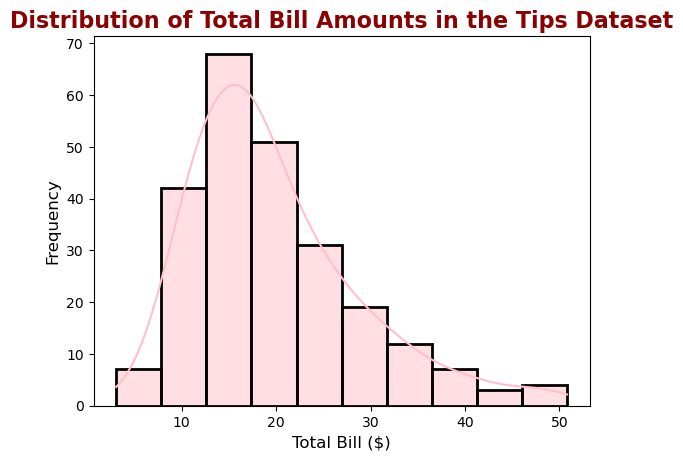

In [6]:
sns.histplot(data=tips,x='total_bill',color='pink',bins=10,edgecolor='black',linewidth=2,kde=True)

plt.title("Distribution of Total Bill Amounts in the Tips Dataset", fontsize=16, fontweight='bold', color='darkred')
plt.xlabel("Total Bill ($)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

### Observations on Total Bill
- Most total bills (68%) fall between \$10 and \$20
- A few very high bills (above \$40) appear to be outliers (only 5% of bills)
- The distribution is right-skewed (mean > median), meaning most bills are small with a few large ones
- This suggests most customers spend moderately, with a few high-spending exceptions


## Count Plot

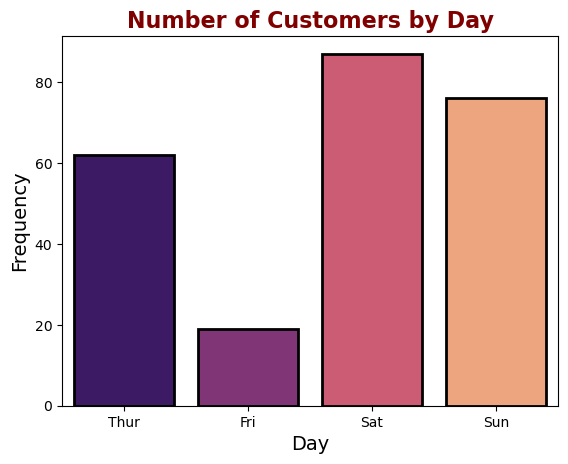

In [9]:
sns.countplot(data=tips,x='day',palette='magma',hue='day',legend=False,edgecolor='black',linewidth=2)

plt.title("Number of Customers by Day", fontsize=16, fontweight='bold', color='maroon')
plt.xlabel('Day',fontsize=14)
plt.ylabel('Frequency',fontsize=14)

plt.show()

#### 🔍 Conclusion

The countplot reveals that **Saturday and Sunday** have the **highest number of customers**, indicating that weekends are the busiest for the restaurant. This suggests increased footfall during weekends, likely due to leisure dining or social gatherings. In contrast, **Thursdays** have comparatively fewer entries, making it one of the quieter days. 

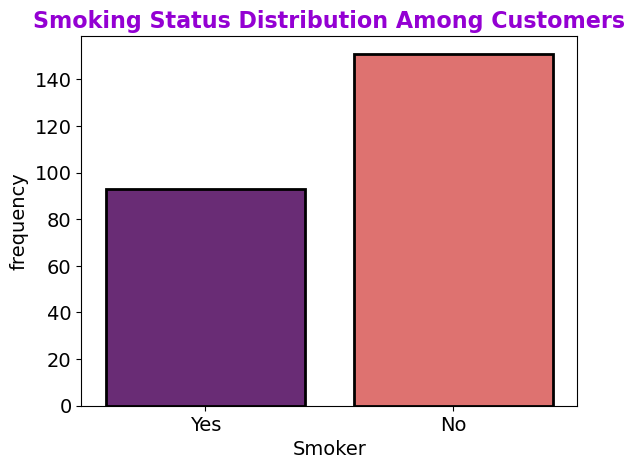

In [25]:
colors = ['#fcfdbf', '#b63679']
sns.countplot(x='smoker',data=tips,palette='magma',hue='smoker',edgecolor='black',linewidth=2 )
plt.title("Smoking Status Distribution Among Customers", fontsize=16, fontweight='bold', color='darkviolet')
plt.xlabel('Smoker',fontsize=14)
plt.ylabel('frequency',fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.show()

#🔍 Conclusion

The distribution plot shows a **higher number of non-smoking customers** compared to smokers. This indicates that the restaurant serves more non-smokers overall. While both groups are present, the business might consider prioritizing non-smoking-friendly environments or promotions, as they represent a larger portion of the customer base. However, the presence of smokers also suggests the need to maintain accommodating spaces or services for them.


## Pie Chart

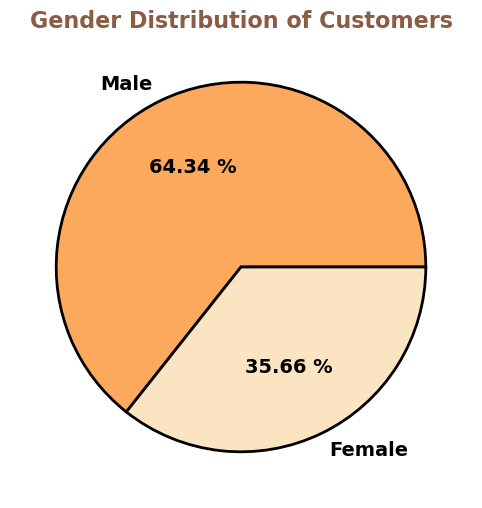

In [10]:
plt.figure(figsize=(8,6))

male=tips.loc[tips['sex']=='Male'].count().iloc[0]
female=tips.loc[tips['sex']=='Female'].count().iloc[0]
label=['Male','Female']

plt.title("Gender Distribution of Customers", fontsize=16, fontweight='bold', color='#8b5c44')
plt.pie([male,female],labels=label,colors=['#fca85d', '#fbe4c2'],autopct='%.2f %%',wedgeprops={"linewidth": 2, "edgecolor": "black"},textprops={'fontsize':14,'fontweight':'bold'})

plt.show()

# Bivariate Analysis

## Bar Plot

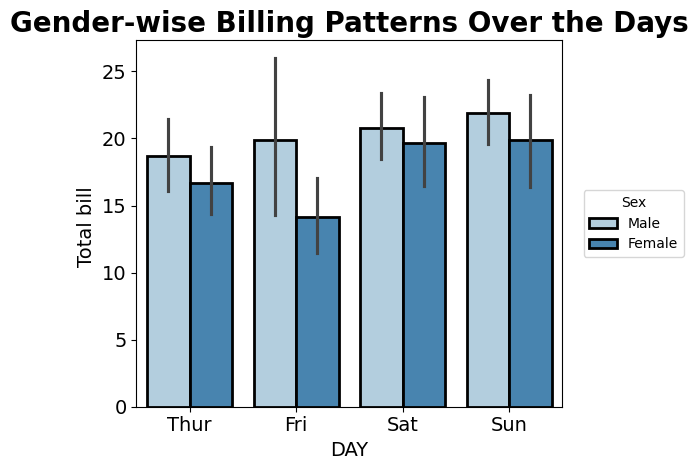

In [38]:
sns.barplot(data=tips,x='day',y='total_bill',hue='sex',palette='Blues',edgecolor='black',linewidth=2 )

plt.title('Gender-wise Billing Patterns Over the Days',fontdict={'fontsize':20,'fontweight':'bold'})

plt.xlabel('DAY',fontsize=14)
plt.ylabel('Total bill ',fontsize=14)

plt.legend(title='Sex', bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0.)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()

## Box Plot

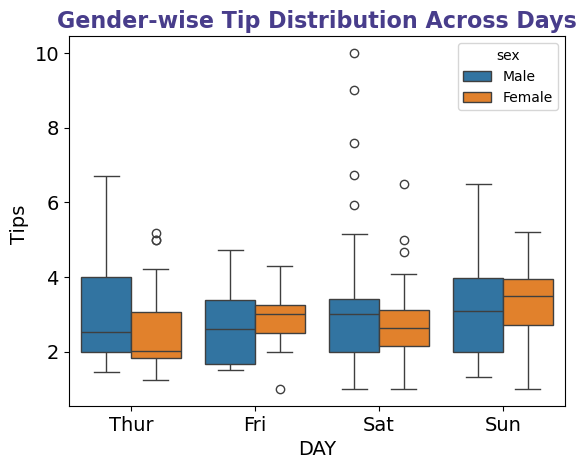

In [33]:
plt.title("Gender-wise Tip Distribution Across Days", fontsize=16, fontweight='bold', color='darkslateblue')

sns.boxplot(x='day',y='tip',hue='sex',data=tips)
plt.xlabel('DAY',fontsize=14)
plt.ylabel('Tips ',fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

## Joint Plot

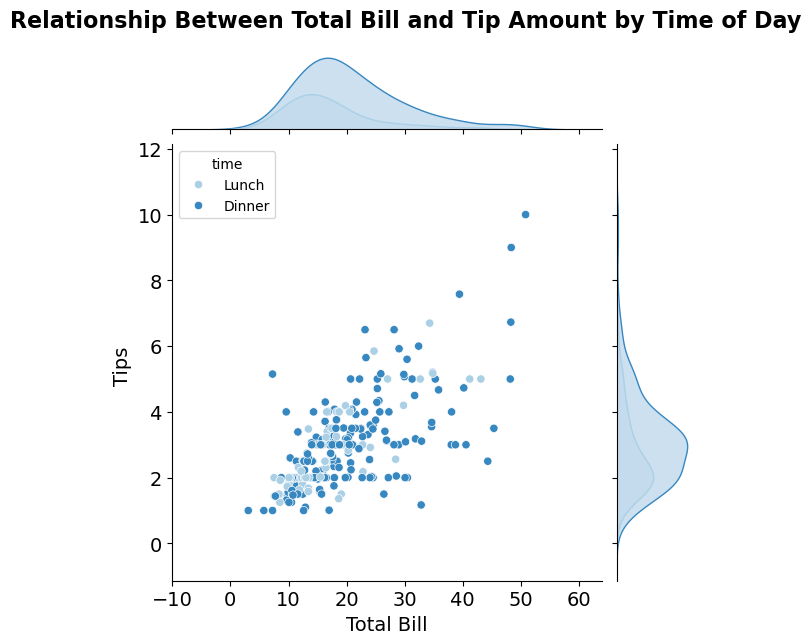

In [48]:
sns.jointplot(x='total_bill',y='tip',data=tips,kind='scatter',hue='time',palette='Blues')
plt.suptitle("Relationship Between Total Bill and Tip Amount by Time of Day", fontsize=16, fontweight='bold', y=1.05)
plt.xlabel('Total Bill',fontsize=14)
plt.ylabel('Tips ',fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.show()


## Swarm Plot

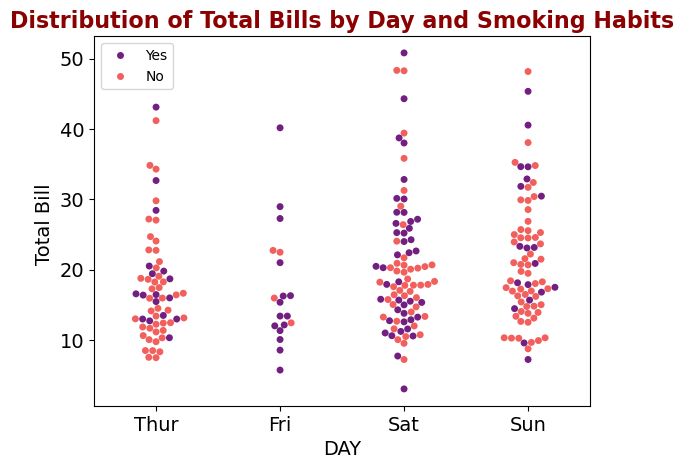

In [62]:
sns.swarmplot(y='total_bill',x='day',data=tips,hue='smoker',palette='magma')
plt.legend(loc=0)
plt.title("Distribution of Total Bills by Day and Smoking Habits", fontsize=16, fontweight='bold', color='darkred')
plt.xlabel('DAY',fontsize=14)
plt.ylabel('Total Bill ',fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

## Heat Map

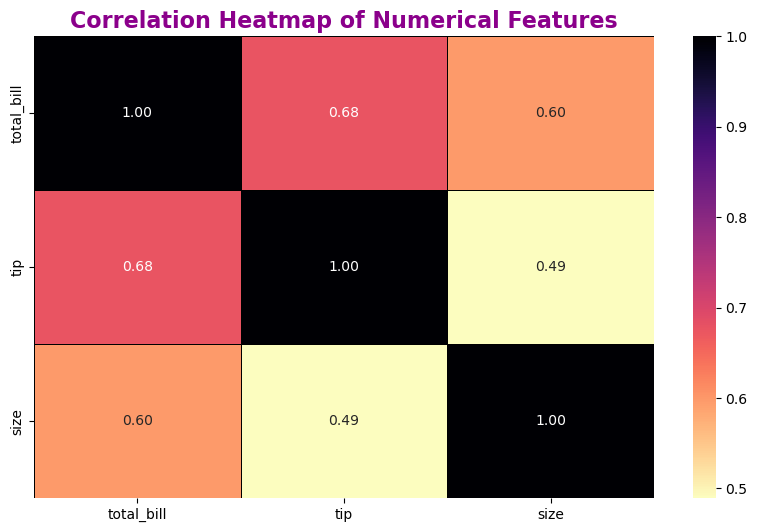

In [67]:
plt.figure(figsize=(10,6))
tp=tips.corr(numeric_only=True)
sns.heatmap(tp,annot=True,cmap='magma_r',linewidths=0.5, linecolor='black', fmt=".2f")

plt.title("Correlation Heatmap of Numerical Features", fontsize=16, fontweight='bold', color='darkmagenta')
plt.show()